# 1. Executive Summary

This notebook follows a CRISP-DM workflow to support a retail banking term deposit campaign.

The objective is to estimate each client's subscription probability and produce a ranked contact list so the bank can prioritize calls more efficiently.

# 2. Business Understanding

## Business Context
Telephone marketing is an important sales channel for term deposits but has high operational cost.

## Analytical Objective
Build a binary classification model to estimate `P(subscription = yes)` for each client.

## Success Criteria
- Good ranking performance (ROC-AUC)
- Practical precision/recall balance
- Usable prioritized contact list for campaign execution

# 3. Data Understanding

In [3]:
# Setup
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

# Configuration
RANDOM_SEED = 42
DATA_PATH = r"C:\Users\migue\Desktop\hackaton ba ntt\data.csv"
TARGET_COL = "y"
ID_COL = None  # Example: "client_id"
CSV_SEPARATOR = ";"  # Change to "," if needed
TEST_SIZE = 0.25

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

In [4]:
# Load dataset
df = pd.read_csv(DATA_PATH, sep=CSV_SEPARATOR)

print(f"Shape: {df.shape}")
display(df.head())

print("\nInfo:")
df.info()

print("\nMissing values per column:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print(f"\nDuplicate rows: {df.duplicated().sum()}")

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

Missing values per column:


,missing_count
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0



Duplicate rows: 0

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


,count
y,
no,39922
yes,5289


,percentage
y,
no,88.3
yes,11.7


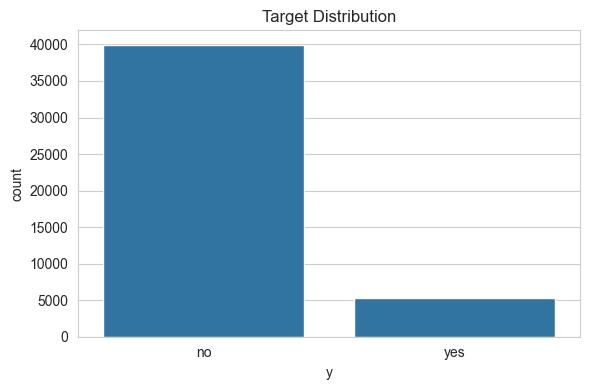

In [5]:
# Target distribution
target_counts = df[TARGET_COL].value_counts(dropna=False)
target_ratio = df[TARGET_COL].value_counts(normalize=True, dropna=False) * 100

display(target_counts.to_frame("count"))
display(target_ratio.round(2).to_frame("percentage"))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET_COL)
plt.title("Target Distribution")
plt.tight_layout()
plt.show()

Numeric columns: 7
Categorical columns: 9


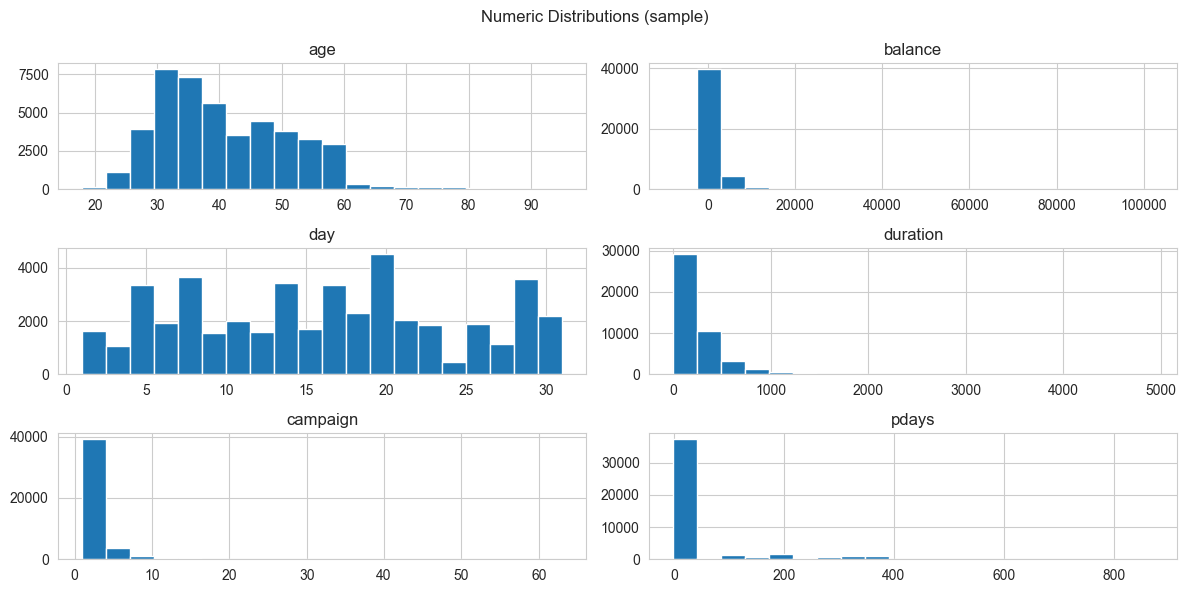

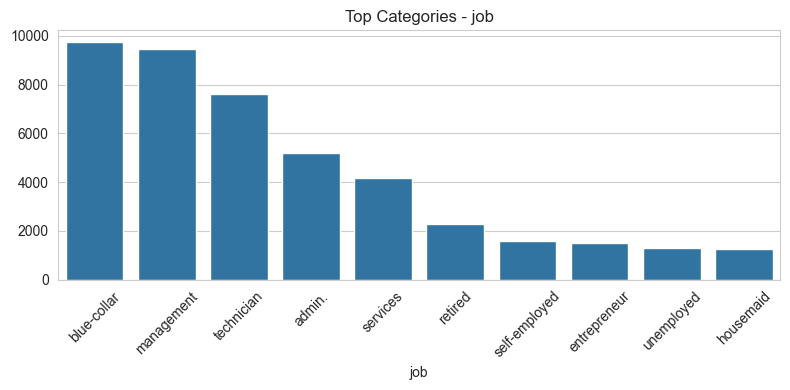

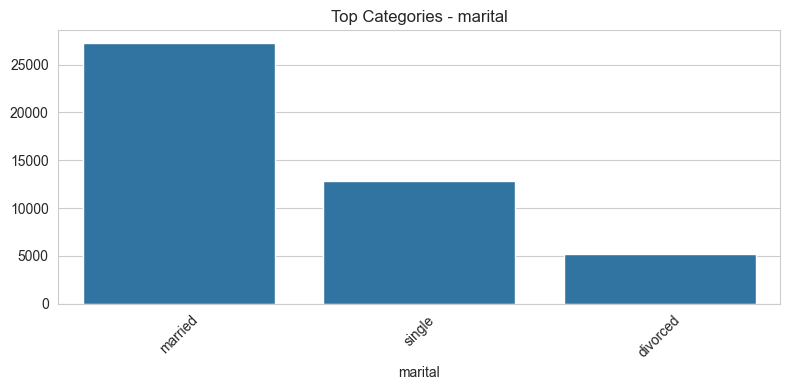

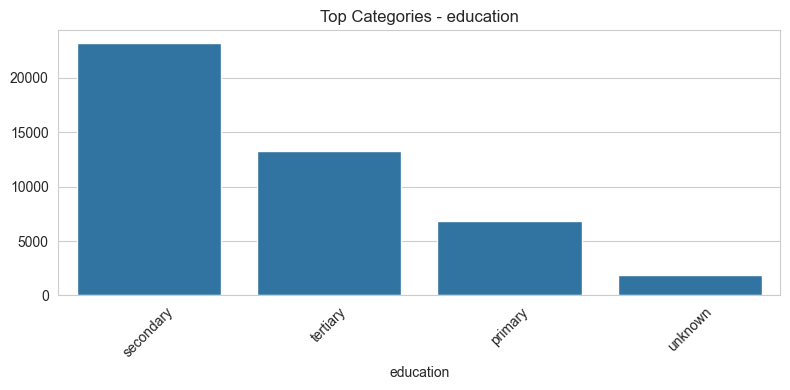

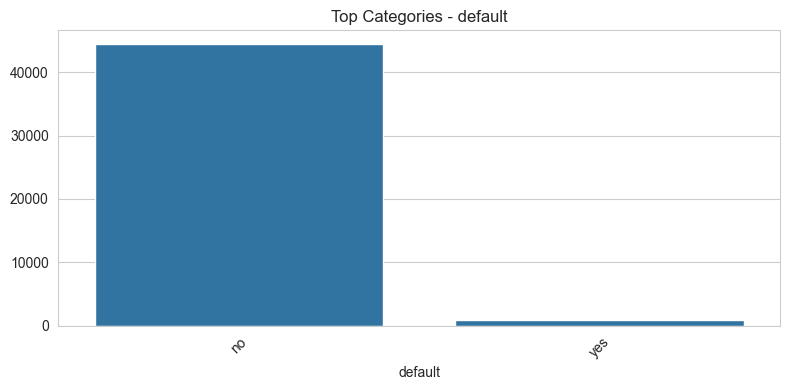

In [6]:
# Simple exploration of numeric and categorical variables
feature_cols = [c for c in df.columns if c != TARGET_COL]
numeric_cols = df[feature_cols].select_dtypes(include=np.number).columns.tolist()
categorical_cols = df[feature_cols].select_dtypes(exclude=np.number).columns.tolist()

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

if numeric_cols:
    numeric_sample = numeric_cols[:6]
    df[numeric_sample].hist(figsize=(12, 6), bins=20)
    plt.suptitle("Numeric Distributions (sample)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, max(4, len(numeric_sample) * 0.7)))
    sns.boxplot(data=df[numeric_sample], orient="h")
    plt.title("Numeric Boxplots (sample)")
    plt.tight_layout()
    plt.show()

for col in categorical_cols[:4]:
    plt.figure(figsize=(8, 4))
    top_values = df[col].value_counts().head(10)
    sns.barplot(x=top_values.index, y=top_values.values)
    plt.title(f"Top Categories - {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 4. Data Preparation

In [ ]:
# Define features and target
X = df.drop(columns=[TARGET_COL]).copy()
y_raw = df[TARGET_COL].copy()

# Convert target to 0/1 (expects yes/no by default)
if y_raw.dtype == "O":
    y = y_raw.astype(str).str.lower().map({"yes": 1, "no": 0})
    if y.isna().any():
        unique_values = sorted(y_raw.dropna().astype(str).unique())
        if len(unique_values) != 2:
            raise ValueError("Target is not binary. Please review TARGET_COL.")
        mapping = {unique_values[0]: 0, unique_values[1]: 1}
        y = y_raw.astype(str).map(mapping)
else:
    y = y_raw.astype(int)

if y.isna().any():
    raise ValueError("Target contains unmapped values. Please review target mapping.")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y,
)

# Identify numeric and categorical columns
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

# Preprocessing pipelines
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# 5. Modeling

In [ ]:
# Baseline and candidate models
models = {
    "Baseline_Dummy": DummyClassifier(strategy="prior", random_state=RANDOM_SEED),
    "Logistic_Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    "Decision_Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_SEED),
    "Random_Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
}

results = []
fitted_models = {}

for name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1_score": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_prob),
        }
    )

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
display(results_df)

# 6. Evaluation

In [ ]:
# Select best model by ROC-AUC
best_model_name = results_df.loc[0, "model"]
best_model = fitted_models[best_model_name]

print(f"Best model: {best_model_name}")

y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

metrics_table = pd.DataFrame(
    {
        "metric": ["accuracy", "precision", "recall", "f1_score", "roc_auc"],
        "value": [
            accuracy_score(y_test, y_pred_best),
            precision_score(y_test, y_pred_best, zero_division=0),
            recall_score(y_test, y_pred_best, zero_division=0),
            f1_score(y_test, y_pred_best, zero_division=0),
            roc_auc_score(y_test, y_prob_best),
        ],
    }
)
display(metrics_table)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob_best)
auc_value = roc_auc_score(y_test, y_prob_best)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC={auc_value:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Build ranked client list for contact priority
if ID_COL is not None and ID_COL in X_test.columns:
    client_ids = X_test[ID_COL].astype(str).values
else:
    client_ids = X_test.index.astype(str)

priority_list = pd.DataFrame(
    {
        "client_id": client_ids,
        "predicted_probability": y_prob_best,
        "predicted_class": (y_prob_best >= 0.50).astype(int),
    }
).sort_values("predicted_probability", ascending=False).reset_index(drop=True)

display(priority_list.head(20))

# 7. Final Recommendations

- **Best model chosen:** Use the top model by ROC-AUC from the comparison table.
- **Main business takeaway:** Predicted probabilities allow the bank to focus calls on higher-likelihood clients and reduce inefficient contacts.
- **Campaign usage:** Start by contacting the top-ranked clients first (e.g., top 10-20%), then expand by available team capacity.
- **Simple next steps:** calibrate decision threshold with business costs, validate on a future campaign period, and retrain regularly with new data.